# Comparing slerp and linear interpolations

In [2]:
import os
os.chdir("..")


In [3]:
import yaml
import sys
from IPython.display import display
from PIL import Image


In [4]:


# === Load config ===
with open("configs/interpolation_sanity_check_base.yaml", "r") as f:
    cfg = yaml.safe_load(f)

exp_name    = cfg["exp_name"]
save_dir = cfg["save_dir"] + '/' + exp_name



In [5]:
from pathlib import Path
import re

save_dir = Path(save_dir)

# Find all .png files
png_files = list(save_dir.glob("*.png"))
png_norm_files = list(save_dir.glob("*norms.png"))

png_files = [f for f in png_files if f not in png_norm_files]


# Group by base name (everything before the last suffix segment before .png)
groups = {}
for f in png_files:
    # Strip the last "_<suffix>" part before .png, e.g. "_l" or "_s"
    match = re.match(r"^(.+)_[^_]+$", f.stem)
    if match:
        base_key = match.group(1)
    else:
        base_key = f.stem  # no suffix found, use full stem as key

    groups.setdefault(base_key, []).append(f)

# Build grouped_files: list of lists, each inner list is a group of related files
grouped_files = [sorted(files) for files in groups.values()]
# Print result
grouped_files = [[str(f) for f in fs] for fs in grouped_files]
png_norm_files = [str(f) for f in png_norm_files]
for group in grouped_files:
    for norm in png_norm_files:
        norm_removed = norm.replace('_norms.png', '.png')
        if norm_removed in group:
            group.append(norm)
    group.sort()
    # print(group)

for group in grouped_files:
    print(group)


['res/interpolation_sanity_check_norms_2/153_Maltese_dog_1_l.png', 'res/interpolation_sanity_check_norms_2/153_Maltese_dog_1_l_norms.png', 'res/interpolation_sanity_check_norms_2/153_Maltese_dog_1_s.png', 'res/interpolation_sanity_check_norms_2/153_Maltese_dog_1_s_norms.png']
['res/interpolation_sanity_check_norms_2/383_Madagascar_cat_1_l.png', 'res/interpolation_sanity_check_norms_2/383_Madagascar_cat_1_l_norms.png', 'res/interpolation_sanity_check_norms_2/383_Madagascar_cat_1_s.png', 'res/interpolation_sanity_check_norms_2/383_Madagascar_cat_1_s_norms.png']
['res/interpolation_sanity_check_norms_2/151_Chihuahua_1_l.png', 'res/interpolation_sanity_check_norms_2/151_Chihuahua_1_l_norms.png', 'res/interpolation_sanity_check_norms_2/151_Chihuahua_1_s.png', 'res/interpolation_sanity_check_norms_2/151_Chihuahua_1_s_norms.png']
['res/interpolation_sanity_check_norms_2/152_Japanese_spaniel_1_l.png', 'res/interpolation_sanity_check_norms_2/152_Japanese_spaniel_1_l_norms.png', 'res/interpolati

Slerp


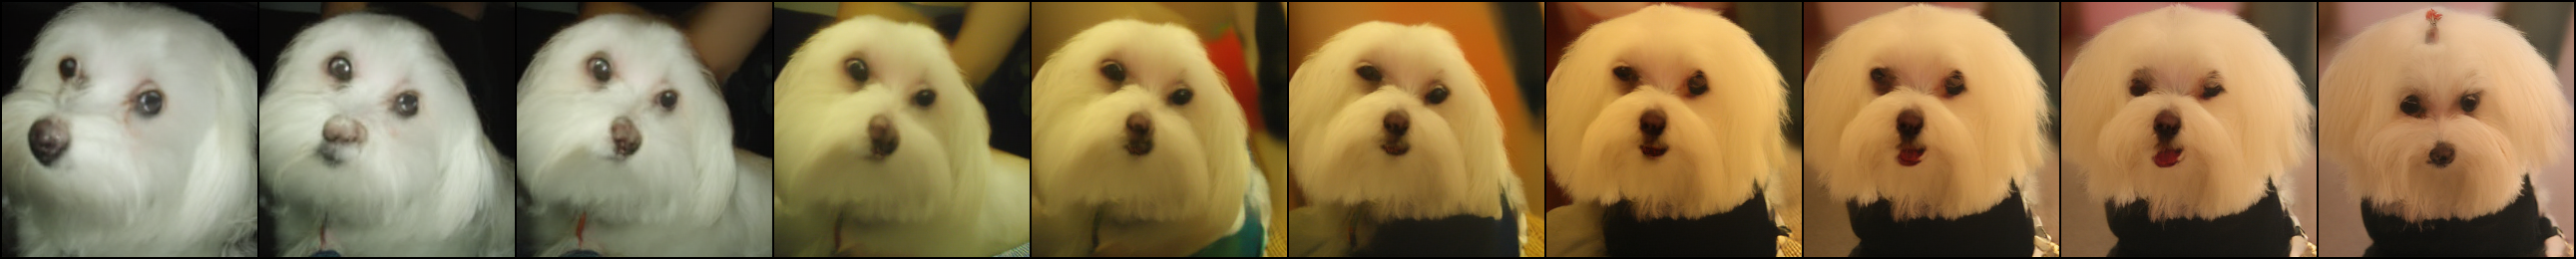

Linear


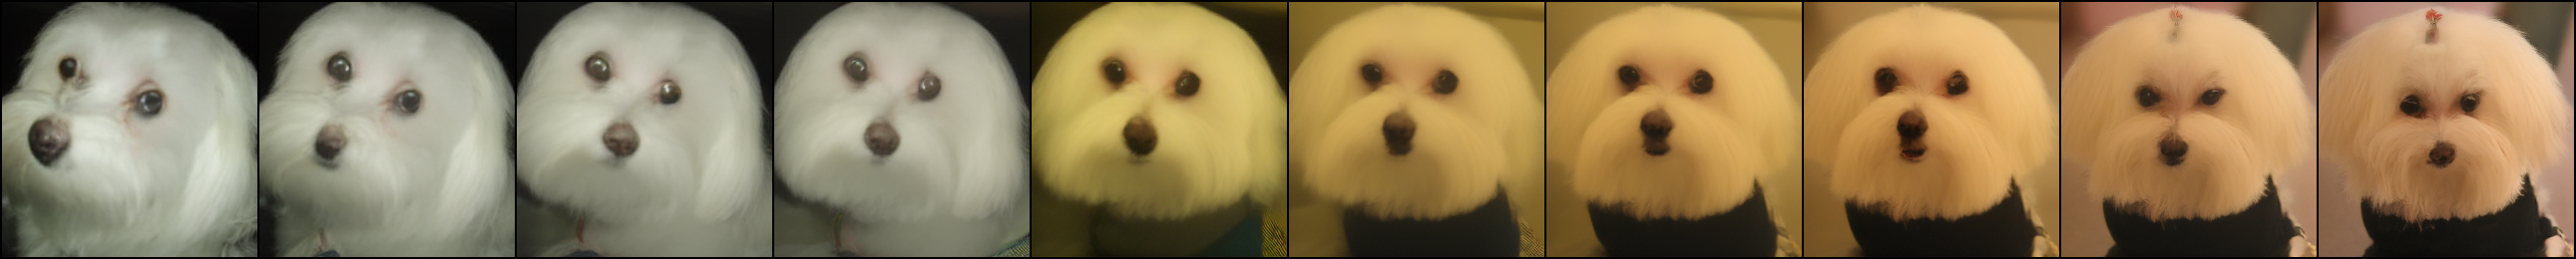

norms (slerp, linear)


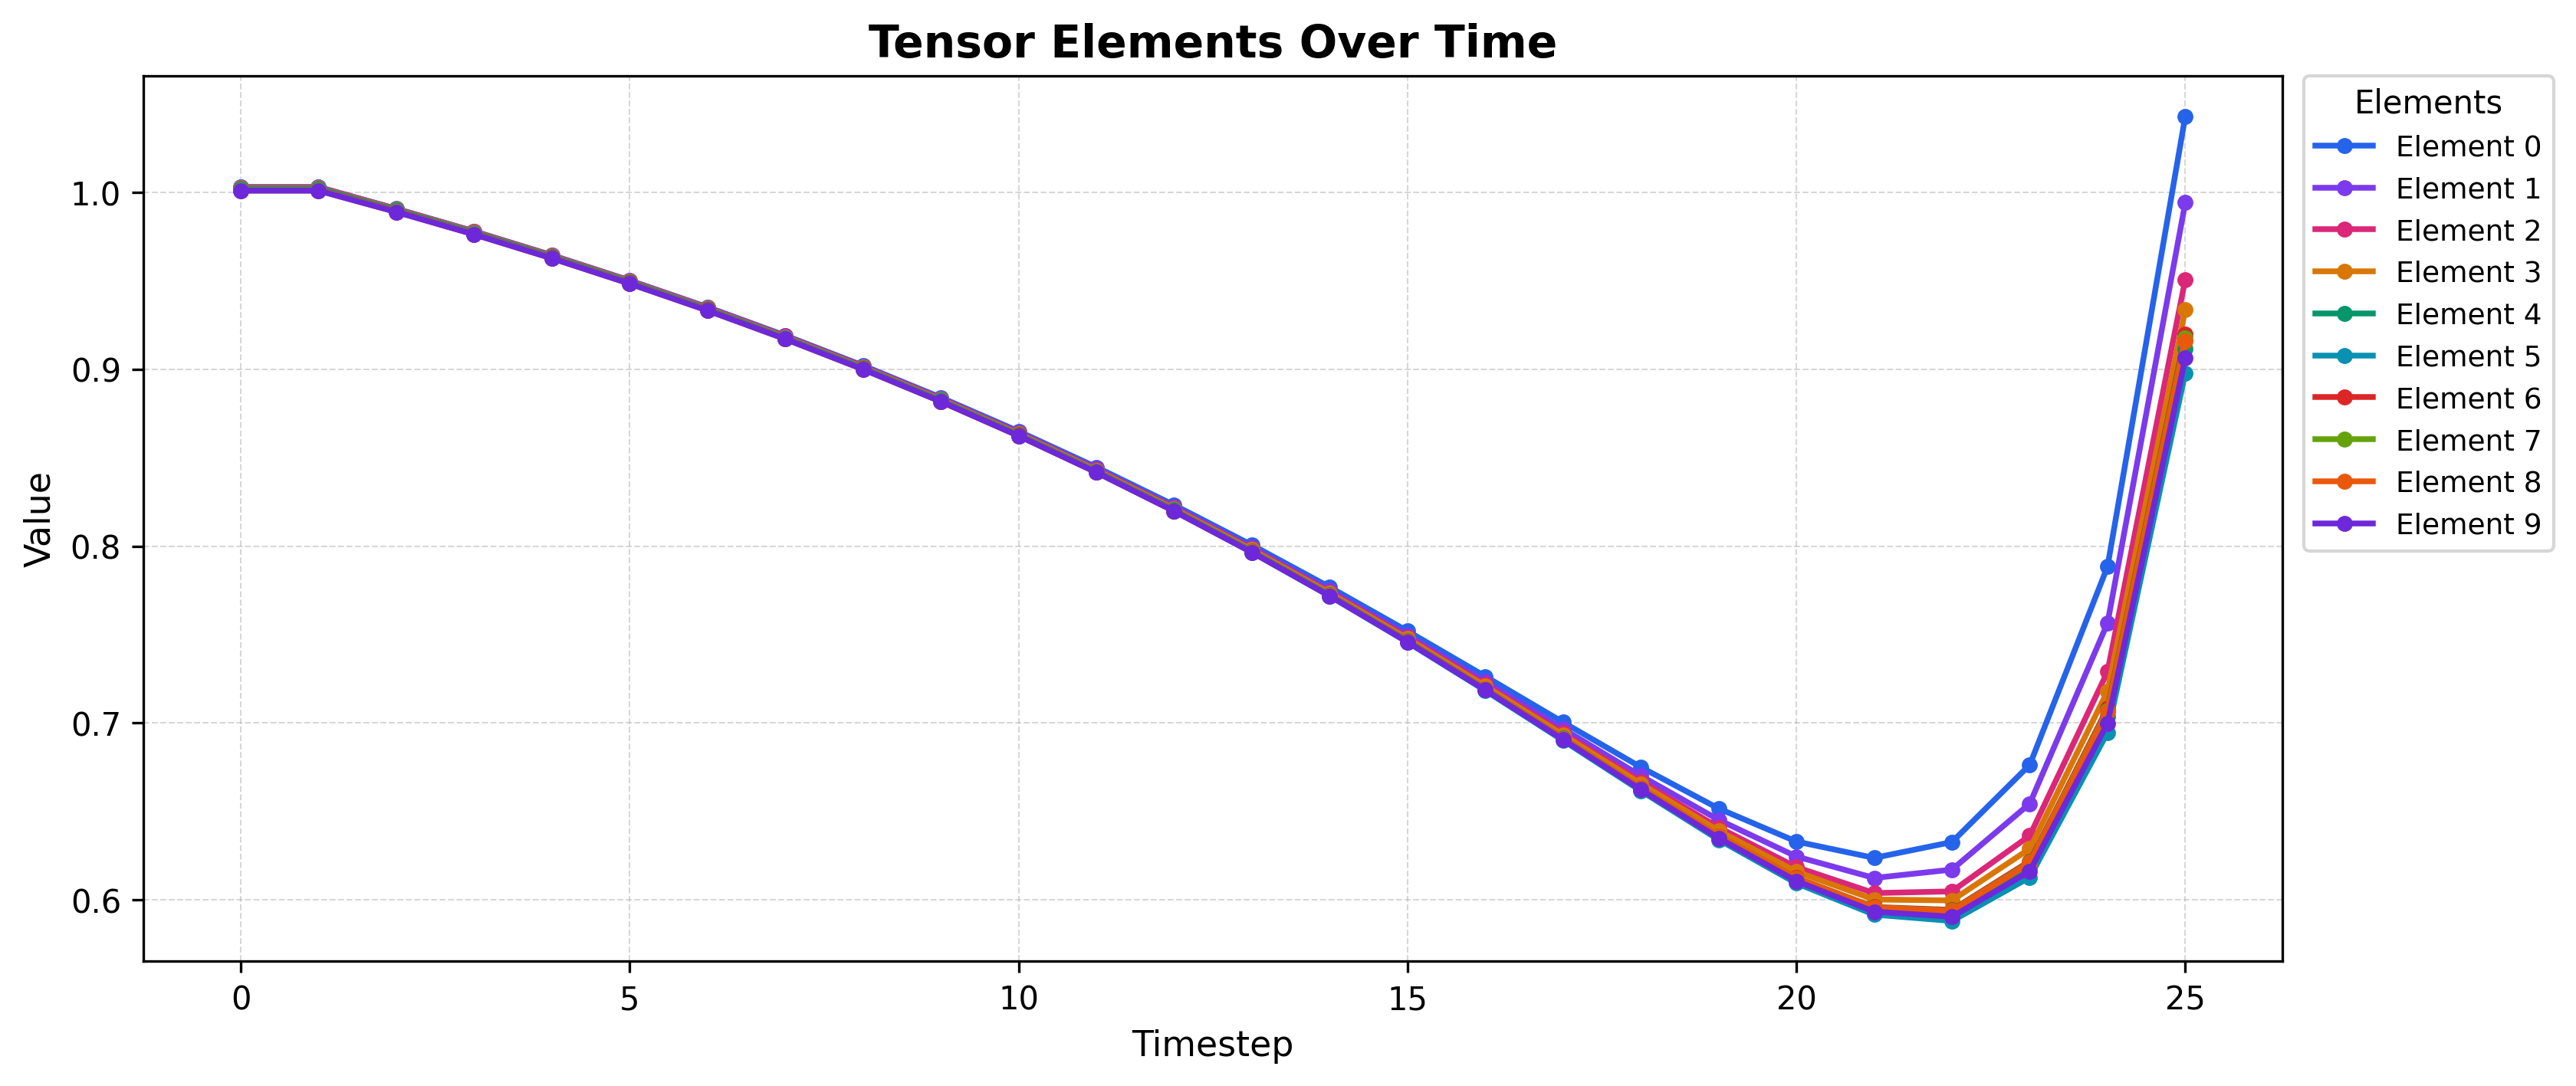

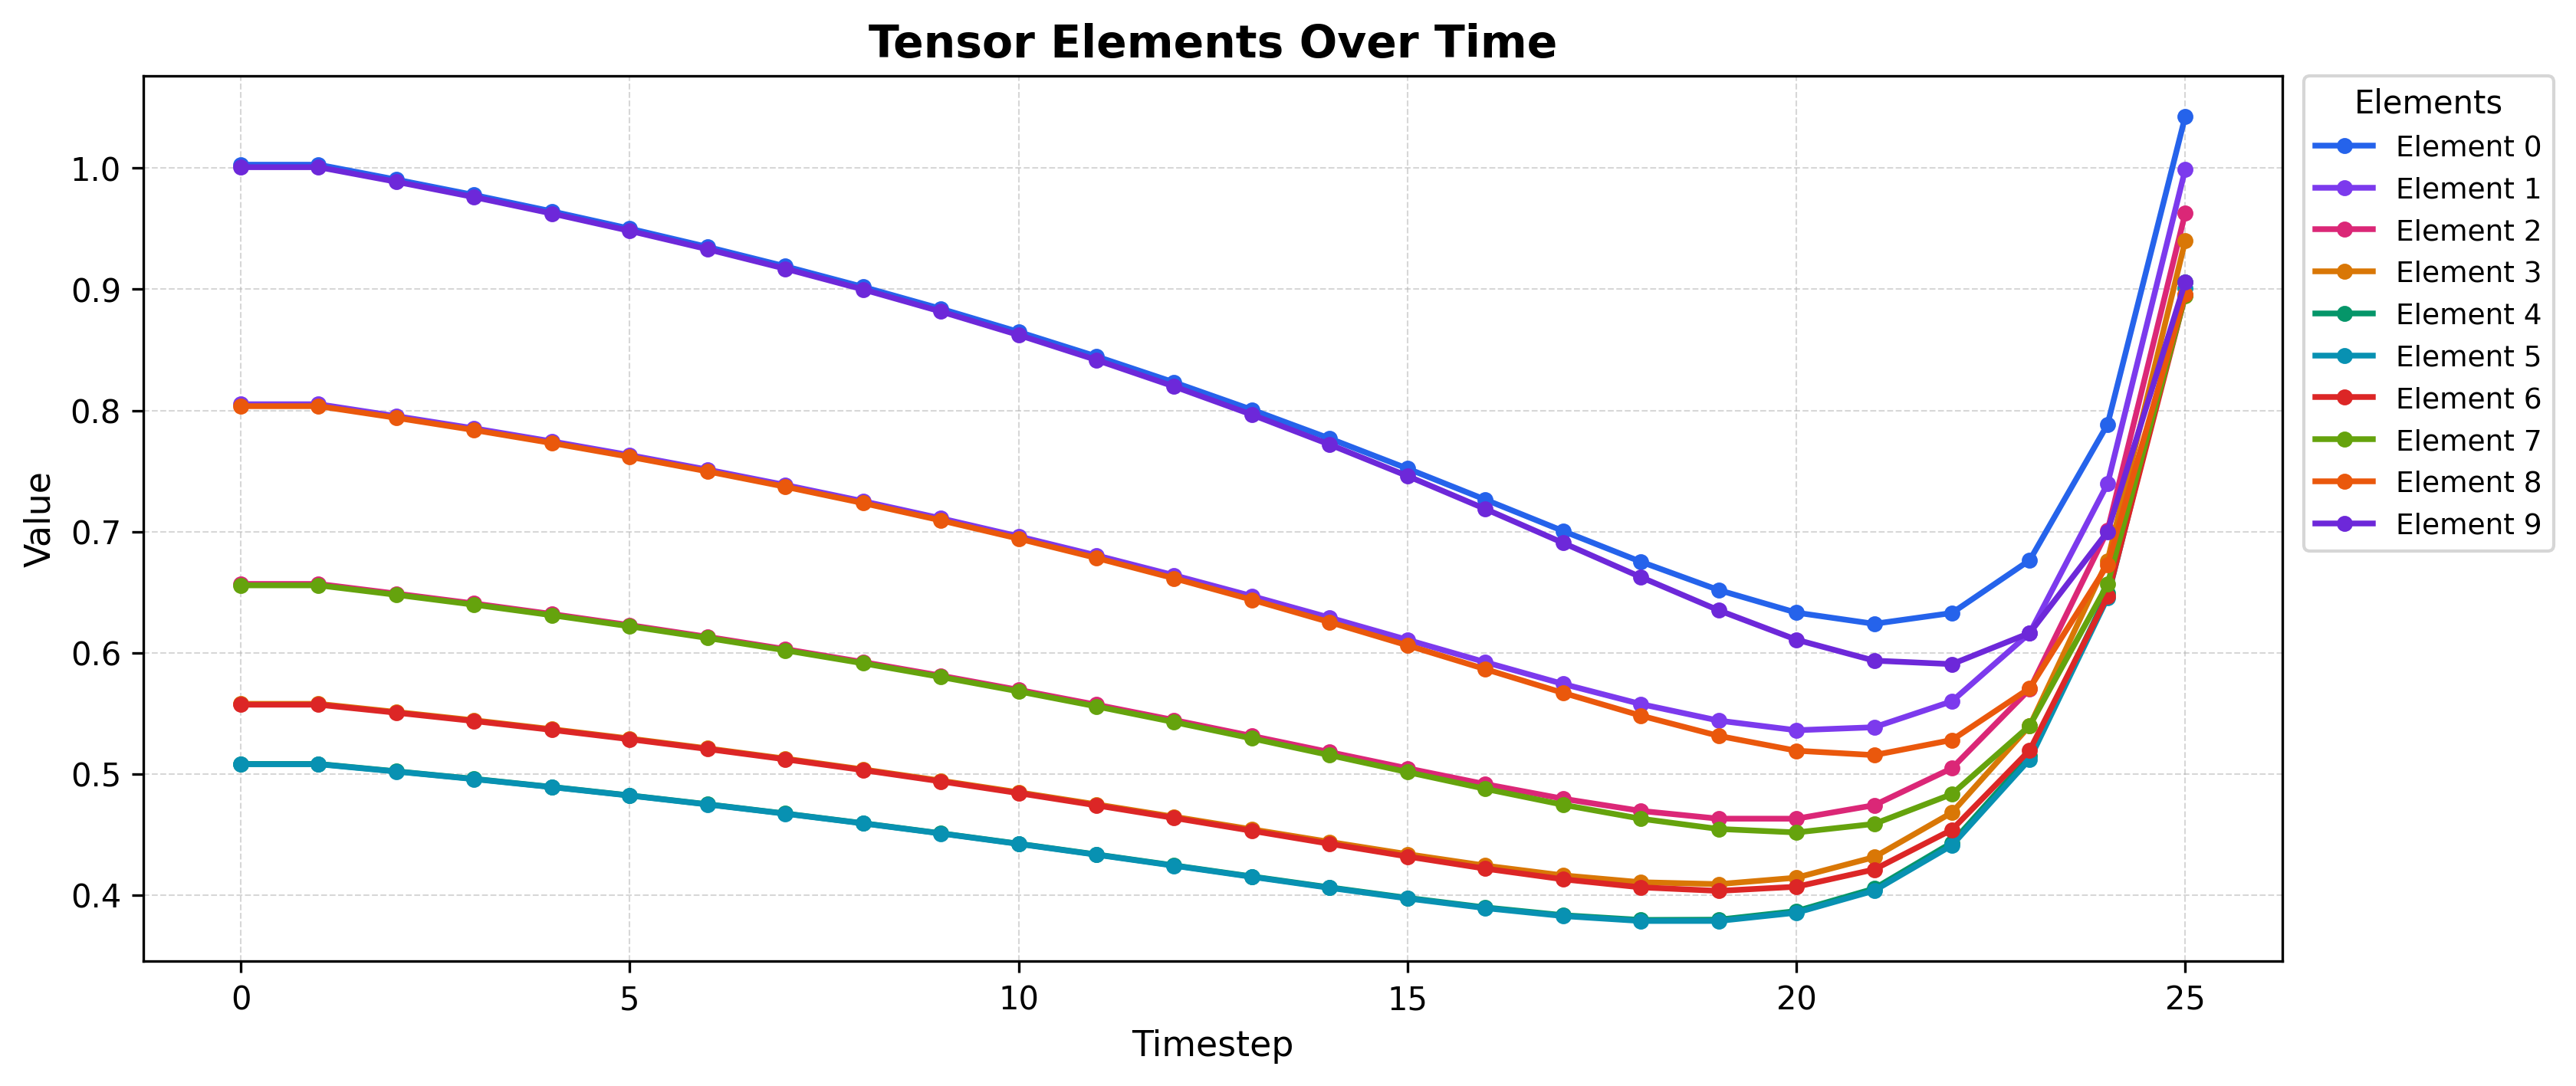

In [ ]:
for path_l, path_l_n, path_s, path_s_n in grouped_files[:1]:
    print('Slerp')
    display(Image.open(path_s))
    print('Linear')
    display(Image.open(path_l))
    print('norms (slerp, linear)')
    display(Image.open(path_s_n))
    display(Image.open(path_l_n))

    print()
    print('=' * 50)
    print()